# The Task

- Import 'wine' dataset
- Choose 10 random data values in the 'residual sugar' coulumn to replace with NaN
- Split the data into TRAIN (has 'residual sugar' values) and TEST (missing values)
- Train the model to predict the missing values.

# Implementation

In [1]:
# Import libraries
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import scipy.stats as stats
import torch.nn.functional as F

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# Import wine dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url,sep=';')
# df = df[df['total sulfur dioxide']<200] # drop a few outliers

display(df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [3]:
df = df.apply(stats.zscore)
display(df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03
mean,3.554936e-16,1.733031e-16,-8.887339e-17,-1.244227e-16,3.732682e-16,-6.221137e-17,4.443669e-17,-3.473172e-14,2.861723e-15,6.754377e-16,1.066481e-16,8.887339e-17
std,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00
min,-2.137045e+00,-2.278280e+00,-1.391472e+00,-1.162696e+00,-1.603945e+00,-1.422500e+00,-1.230584e+00,-3.538731e+00,-3.700401e+00,-1.936507e+00,-1.898919e+00,-3.265165e+00
25%,-7.007187e-01,-7.699311e-01,-9.293181e-01,-4.532184e-01,-3.712290e-01,-8.487156e-01,-7.440403e-01,-6.077557e-01,-6.551405e-01,-6.382196e-01,-8.663789e-01,-7.878226e-01
50%,-2.410944e-01,-4.368911e-02,-5.636026e-02,-2.403750e-01,-1.799455e-01,-1.793002e-01,-2.574968e-01,1.760083e-03,-7.212705e-03,-2.251281e-01,-2.093081e-01,4.508484e-01
75%,5.057952e-01,6.266881e-01,7.652471e-01,4.341614e-02,5.384542e-02,4.901152e-01,4.723184e-01,5.768249e-01,5.759223e-01,4.240158e-01,6.354971e-01,4.508484e-01
max,4.355149e+00,5.877976e+00,3.743574e+00,9.195681e+00,1.112703e+01,5.367284e+00,7.375154e+00,3.680055e+00,4.528282e+00,7.918677e+00,4.202453e+00,2.928190e+00


In [4]:
def split_data(df, batchsize:int=4, test_size:int=10):
    '''
    Split data from a dataframe into train and test DataLoader objects.
    The TEST dataset contains num_nan NaN values in the labels. 
    Args:
        df (pd.DataFrame): Dataframe containing the data to be split.
        batchsize (int): Batch size for the training DataLoader.
        test_size (int): Number of NaN values to insert into the test labels (also used as the test set size).
    Returns:
        train_loader (DataLoader): DataLoader for the training data.
        test_loader (DataLoader): DataLoader for the test data with NaN values in labels.
        test_loader_true_labels (torch.Tensor): Original labels of the test data before inserting NaNs
    '''
    
    assert test_size > 0.0, 'test_size must be positive non-zero'
    
    # Step 1: Extract data from dataframe
    data = torch.tensor(df.drop('residual sugar', axis=1).values).float()
    labels = torch.tensor(df.loc[:,'residual sugar'].values).float().unsqueeze(1)

    # Step 2: use scikitlearn to split the data
    train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=test_size)
    
    # Step 3: convert into PyTorch Datasets
    train_data = torch.utils.data.TensorDataset(train_data,train_labels)
    test_data  = torch.utils.data.TensorDataset(test_data,test_labels)
    
    # Step 4: translate into dataloader objects
    train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
    test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])
    
    # Replace N=10 values in the test_loader with NaN
    N = min(test_size, test_loader.dataset.tensors[1].shape[0])
    nan_indices = np.random.choice(test_loader.dataset.tensors[1].shape[0], size=N, replace=False)
    test_loader_true_labels = test_loader.dataset.tensors[1].clone()
    test_loader.dataset.tensors[1][nan_indices] = float('nan')
    
    return train_loader, test_loader, test_loader_true_labels

In [5]:
# Test data generation function:
train_loader, test_loader, test_loader_true_labels = split_data(df, batchsize=16, test_size=10)

print('df.shape =', df.shape)
print('train_loader.dataset.tensors[0].shape =', train_loader.dataset.tensors[0].shape)
print('train_loader.dataset.tensors[1].shape =', train_loader.dataset.tensors[1].shape)
print('test_loader.dataset.tensors[0].shape =', test_loader.dataset.tensors[0].shape)
print('test_loader.dataset.tensors[1].shape =', test_loader.dataset.tensors[1].shape)
# print('test_loader.dataset.tensors[0] =', test_loader.dataset.tensors[0])
print('test_loader.dataset.tensors[1]:\n', test_loader.dataset.tensors[1])
print('test_loader_true_labels:\n', test_loader_true_labels)
print('Total samples =', train_loader.dataset.tensors[0].shape[0] + test_loader.dataset.tensors[0].shape[0])

df.shape = (1599, 12)
train_loader.dataset.tensors[0].shape = torch.Size([1589, 11])
train_loader.dataset.tensors[1].shape = torch.Size([1589, 1])
test_loader.dataset.tensors[0].shape = torch.Size([10, 11])
test_loader.dataset.tensors[1].shape = torch.Size([10, 1])
test_loader.dataset.tensors[1]:
 tensor([[nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan],
        [nan]])
test_loader_true_labels:
 tensor([[-0.2404],
        [-0.1694],
        [-0.1694],
        [-0.3113],
        [-0.3113],
        [-0.5242],
        [-0.5951],
        [-0.3823],
        [-0.0985],
        [ 1.4624]])
Total samples = 1599


In [6]:
# Function to create a model
def createNet(lr:float=.1e-2):
    class Net(nn.Module):
        def __init__(self, nFeatures:int=11, nTargets:int=1):
            super().__init__()
            
            self.actfun = F.relu
            
            self.input = nn.Linear(nFeatures,16)
            self.hidden1 = nn.Linear(self.input.out_features,64)
            self.output = nn.Linear(self.hidden1.out_features,nTargets)

        def forward(self, x):
            x = self.actfun(self.input(x))
            x = self.actfun(self.hidden1(x))
            return self.output(x)
 
    net = Net()
    lossfun = nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(),lr=lr)
    
    return net, lossfun, optimizer

# Run model on dummy data
net, lossfun, optimizer = createNet()
X,y = next(iter(test_loader))
yHat = net(X)
loss = lossfun(yHat, test_loader_true_labels)
print(f'Dummy data MSE loss: {loss.item():.4f}')

Dummy data MSE loss: 0.4401


In [7]:
# Function to train the model
def train_the_model(train_loader, numepochs:int=10, lr:float=1e-2):
    net, lossfun, optimizer = createNet(lr=lr)
    
    # initialize losses
    losses = torch.zeros(numepochs)
    
    # loop over epochs
    for epochi in range(numepochs):
        # loop over training data batches
        batchAcc  = torch.zeros((train_loader.dataset.tensors[0].shape[0] // train_loader.batch_size) + 1)
        batchLoss = torch.zeros((train_loader.dataset.tensors[0].shape[0] // train_loader.batch_size) + 1)
        
        batchi = 0
        for X,y in train_loader:
            # forward pass and loss
            yHat = net(X)
            loss = lossfun(yHat,y)

            # backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Store batch loss and accuracy
            batchLoss[batchi] = loss.item()
            batchi += 1
            # end of batch loop...

        # and get average losses across the batches
        losses[epochi] = torch.mean(batchLoss[:batchi]).item()
    # end epochs

    # function output
    return losses, net

In [15]:
# Generate sample data:
train_loader, test_loader, test_loader_true_labels = split_data(df, batchsize=16)
test_loader_true_labels = test_loader_true_labels.detach().numpy().flatten()

# Train the model
numepochs = 500
losses, net = train_the_model(train_loader, numepochs=numepochs, lr=1e-3)

In [16]:
# Test the model on test data
X_test, y_test = next(iter(test_loader))
net.eval()
with torch.no_grad(): # deactivates autograd
    yHat_test = net(X_test).detach().numpy().flatten()
r_test = np.corrcoef(test_loader_true_labels, yHat_test)[0, 1]

# Predict on train dataset for comparison
train_loader_tmp = DataLoader(train_loader.dataset, batch_size=len(train_loader.dataset))
X_train, y_train = next(iter(train_loader_tmp))
y_train  = y_train.detach().numpy().flatten()
net.eval()
with torch.no_grad(): # deactivates autograd
    yHat_train = net(X_train).detach().numpy().flatten()
r_train = np.corrcoef(y_train, yHat_train)[0, 1]

# Print test results
for t,p in zip(test_loader_true_labels, yHat_test):
    print(f'T: {t:.2f} P: {p:.2f}')

T: -0.17 P: -0.23
T: -0.38 P: -0.51
T: -0.60 P: -0.57
T: -0.45 P: 0.04
T: 0.54 P: 0.97
T: -0.31 P: 0.19
T: -0.31 P: -0.38
T: -0.67 P: -0.47
T: -0.45 P: -0.44
T: -0.03 P: -0.07


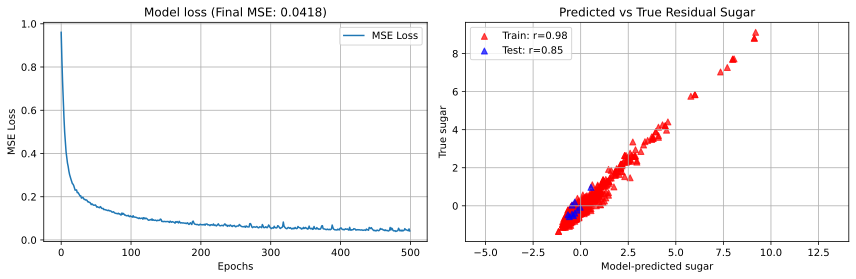

In [17]:
# Visualize training and testing results
fig,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(losses, label='MSE Loss')
axs[0].set_ylabel('MSE Loss')
axs[0].set_xlabel('Epochs') 
axs[0].set_title(f'Model loss (Final MSE: {losses[-1]:.4f})')
axs[0].legend(loc='best')
axs[0].grid(True)

axs[1].scatter(y_train, yHat_train, marker='^', alpha=0.7, color='red', label=f'Train: r={r_train:.2f}')
axs[1].scatter(test_loader_true_labels, yHat_test, marker='^', alpha=0.7, color='blue', label=f'Test: r={r_test:.2f}')
axs[1].set_xlabel('Model-predicted sugar')
axs[1].set_ylabel('True sugar')
axs[1].set_title('Predicted vs True Residual Sugar')
axs[1].axis('equal')
axs[1].legend(loc='best')
axs[1].grid(True)

fig.tight_layout()
plt.show()